In [2]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
base = Path("../dataset_trabalho")

classe_saudavel = "orange"
classe_podre = "rottenoranges"

pasta_saudavel = base / classe_saudavel
pasta_podre = base / classe_podre

imagens_saudaveis = sorted(list(pasta_saudavel.glob("*")))
imagens_podres = sorted(list(pasta_podre.glob("*")))

print("Pasta saudável:", pasta_saudavel)
print("Existe?", pasta_saudavel.exists())
print("Saudáveis:", len(imagens_saudaveis))

print("Pasta podre:", pasta_podre)
print("Existe?", pasta_podre.exists())
print("Podres:", len(imagens_podres))

Pasta saudável: ..\dataset_trabalho\orange
Existe? True
Saudáveis: 100
Pasta podre: ..\dataset_trabalho\rottenoranges
Existe? True
Podres: 100


# ## Segmentação HSV usada para extrair features

In [120]:
def segmentar_hsv(caminho_img, limite_saturacao=40):
    img_bgr = cv2.imread(str(caminho_img))
    
    if img_bgr is None:
        raise ValueError(f"Erro ao carregar imagem: {caminho_img}")
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(img_hsv)

    mascara = cv2.inRange(s, limite_saturacao, 255)

    kernel = np.ones((5, 5), np.uint8)
    mascara_limpa = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    mascara_limpa = cv2.morphologyEx(mascara_limpa, cv2.MORPH_CLOSE, kernel)

    return img_bgr, img_rgb, mascara_limpa

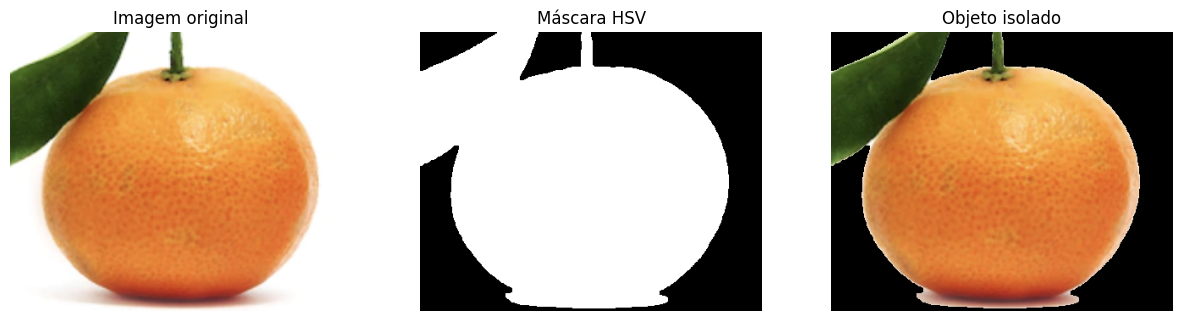

In [121]:
caminho_img = imagens_saudaveis[0]

img_bgr, img_rgb, mascara = segmentar_hsv(caminho_img)

resultado = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagem original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mascara, cmap="gray")
plt.title("Máscara HSV")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(resultado)
plt.title("Objeto isolado")
plt.axis("off")

plt.show()

## Features de forma

In [122]:
def extrair_features_forma(mascara):
    contornos, _ = cv2.findContours(
        mascara,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contornos) == 0:
        return None

    maior_contorno = max(contornos, key=cv2.contourArea)

    area = cv2.contourArea(maior_contorno)
    perimetro = cv2.arcLength(maior_contorno, True)

    x, y, w, h = cv2.boundingRect(maior_contorno)
    area_retangulo = w * h

    if area_retangulo > 0:
        extent = area / area_retangulo
    else:
        extent = 0

    if perimetro > 0:
        circularidade = (4 * np.pi * area) / (perimetro ** 2)
    else:
        circularidade = 0

    return {
        "area": area,
        "perimetro": perimetro,
        "extent": extent,
        "circularidade": circularidade
    }

In [123]:
features_forma = extrair_features_forma(mascara)
features_forma

{'area': 86761.5,
 'perimetro': 1431.8447939157486,
 'extent': 0.7269196933517658,
 'circularidade': 0.5317959508838614}

In [124]:
## As features de forma representam características geométricas da fruta segmentada. A área mede o tamanho do objeto em pixels, 
# o perímetro mede o contorno externo, o extent indica quanto o objeto ocupa dentro do retângulo delimitador e a circularidade indica
#  o quanto o formato se aproxima de um círculo. Como a laranja possui formato aproximadamente circular, essas medidas ajudam a
#  identificar deformações ou problemas de segmentação

## Momentos de Hu

In [125]:
#Os momentos de Hu são descritores de forma calculados a partir da máscara do objeto. Eles ajudam a representar características geométricas
#  da fruta de uma forma mais compacta. Neste projeto, eles complementam as features simples de forma, como área, perímetro e circularidade.

In [126]:
def extrair_momentos_hu(mascara):
    # Calcula os momentos da máscara
    momentos = cv2.moments(mascara)

    # Calcula os 7 momentos de Hu
    hu = cv2.HuMoments(momentos).flatten()

    # Aplica escala logarítmica para facilitar a análise dos valores
    hu_log = []

    for valor in hu:
        if valor == 0:
            hu_log.append(0)
        else:
            hu_log.append(-np.sign(valor) * np.log10(abs(valor)))

    # Retorna os momentos em formato de dicionário
    return {
        f"hu_{i+1}": hu_log[i]
        for i in range(7)
    }

In [127]:
features_hu = extrair_momentos_hu(mascara)
features_hu

{'hu_1': np.float64(3.176217579112128),
 'hu_2': np.float64(7.553883891555429),
 'hu_3': np.float64(10.80349884643368),
 'hu_4': np.float64(12.064052454659395),
 'hu_5': np.float64(23.57517919158918),
 'hu_6': np.float64(15.987211283979878),
 'hu_7': np.float64(-23.759500741799744)}

In [128]:
#Os momentos de Hu foram calculados a partir da máscara gerada pela segmentação HSV. Eles representam características geométricas do objeto
#  segmentado. Como são valores muito pequenos originalmente, foi aplicada escala logarítmica para facilitar a análise e comparação entre imagens.

## Features de cor

In [129]:
#As features de cor são importantes porque laranjas podres geralmente apresentam mudanças visuais como escurecimento, manchas, regiões
#  esbranquiçadas, perda de brilho e variação irregular de cor. Por isso, serão analisadas médias dos canais RGB e HSV dentro da região
#  segmentada pela máscara.

In [130]:
# Escolhe uma imagem para testar
caminho_img = imagens_saudaveis[0]

# Gera imagem e máscara usando a segmentação HSV
img_bgr, img_rgb, mascara = segmentar_hsv(caminho_img)

# Agora cria a imagem em HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Pega somente os pixels dentro da máscara
pixels_hsv = img_hsv[mascara > 0]
pixels_rgb = img_rgb[mascara > 0]

# Médias HSV
media_h = np.mean(pixels_hsv[:, 0])
media_s = np.mean(pixels_hsv[:, 1])
media_v = np.mean(pixels_hsv[:, 2])

# Médias RGB
media_r = np.mean(pixels_rgb[:, 0])
media_g = np.mean(pixels_rgb[:, 1])
media_b = np.mean(pixels_rgb[:, 2])

features_cor = {
    "media_h": media_h,
    "media_s": media_s,
    "media_v": media_v,
    "media_r": media_r,
    "media_g": media_g,
    "media_b": media_b
}

features_cor

{'media_h': np.float64(18.084059861330406),
 'media_s': np.float64(175.32534724605844),
 'media_v': np.float64(200.92767900048054),
 'media_r': np.float64(198.12948216287955),
 'media_g': np.float64(127.71496075604678),
 'media_b': np.float64(62.54053682982083)}

## Features de textura

In [131]:
#As features de textura ajudam a representar irregularidades na superfície da fruta, como manchas, mofo, rugosidade e regiões deterioradas.
#  Essas características são importantes porque laranjas podres tendem a ter aparência menos uniforme do que laranjas saudáveis.

In [132]:
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [133]:
from skimage.feature import graycomatrix, graycoprops

In [134]:
def extrair_features_textura_glcm(img_bgr, mascara):
    # Converte a imagem para escala de cinza
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Encontra os pixels pertencentes ao objeto
    coords = np.column_stack(np.where(mascara > 0))

    if len(coords) == 0:
        return {
            "glcm_contrast": 0,
            "glcm_homogeneity": 0,
            "glcm_energy": 0,
            "glcm_correlation": 0
        }

    # Recorta a região onde está o objeto
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    recorte_gray = img_gray[y_min:y_max + 1, x_min:x_max + 1]
    recorte_mascara = mascara[y_min:y_max + 1, x_min:x_max + 1]

    # Substitui o fundo pelo valor mediano da fruta
    # Isso reduz a influência do fundo na textura
    pixels_objeto = recorte_gray[recorte_mascara > 0]
    valor_mediano = int(np.median(pixels_objeto))

    recorte_gray_limpo = recorte_gray.copy()
    recorte_gray_limpo[recorte_mascara == 0] = valor_mediano

    # Reduz os níveis de cinza de 256 para 32
    # Isso deixa a GLCM mais leve
    recorte_reduzido = (recorte_gray_limpo / 8).astype(np.uint8)

    # Calcula a matriz GLCM
    glcm = graycomatrix(
        recorte_reduzido,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=32,
        symmetric=True,
        normed=True
    )

    # Calcula propriedades de textura
    contraste = graycoprops(glcm, "contrast").mean()
    homogeneidade = graycoprops(glcm, "homogeneity").mean()
    energia = graycoprops(glcm, "energy").mean()
    correlacao = graycoprops(glcm, "correlation").mean()

    return {
        "glcm_contrast": contraste,
        "glcm_homogeneity": homogeneidade,
        "glcm_energy": energia,
        "glcm_correlation": correlacao
    }

In [135]:
features_textura = extrair_features_textura_glcm(img_bgr, mascara)
features_textura

{'glcm_contrast': np.float64(1.077351186139229),
 'glcm_homogeneity': np.float64(0.8735075849087072),
 'glcm_energy': np.float64(0.3699388359901193),
 'glcm_correlation': np.float64(0.974749919852585)}

In [136]:
#Foram extraídas quatro propriedades de textura usando GLCM: contraste, homogeneidade, energia e correlação. O contraste mede variações de
#  intensidade na imagem, a homogeneidade indica o quanto a textura é uniforme, a energia mede a repetição de padrões e a correlação mede a 
# relação entre pixels vizinhos. Essas medidas são úteis para diferenciar superfícies mais regulares de superfícies com manchas, mofo ou
#  deterioração.

## Montagem da tabela X e vetor y

In [137]:
import pandas as pd

In [138]:
features_textura = extrair_features_textura_glcm(img_bgr, mascara)
features_textura

{'glcm_contrast': np.float64(1.077351186139229),
 'glcm_homogeneity': np.float64(0.8735075849087072),
 'glcm_energy': np.float64(0.3699388359901193),
 'glcm_correlation': np.float64(0.974749919852585)}

In [139]:
def extrair_features_imagem(caminho_img):
    img_bgr, img_rgb, mascara = segmentar_hsv(caminho_img)

    features = {}

    # Forma
    features_forma = extrair_features_forma(mascara)
    if features_forma is not None:
        features.update(features_forma)

    # Momentos de Hu
    features_hu = extrair_momentos_hu(mascara)
    features.update(features_hu)

    # Cor
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    pixels_hsv = img_hsv[mascara > 0]
    pixels_rgb = img_rgb[mascara > 0]

    features_cor = {
        "media_h": np.mean(pixels_hsv[:, 0]),
        "media_s": np.mean(pixels_hsv[:, 1]),
        "media_v": np.mean(pixels_hsv[:, 2]),
        "media_r": np.mean(pixels_rgb[:, 0]),
        "media_g": np.mean(pixels_rgb[:, 1]),
        "media_b": np.mean(pixels_rgb[:, 2])
    }

    features.update(features_cor)

    # Textura
    features_textura = extrair_features_textura_glcm(img_bgr, mascara)
    features.update(features_textura)

    return features

In [140]:
teste = extrair_features_imagem(imagens_saudaveis[0])
teste

{'area': 86761.5,
 'perimetro': 1431.8447939157486,
 'extent': 0.7269196933517658,
 'circularidade': 0.5317959508838614,
 'hu_1': np.float64(3.176217579112128),
 'hu_2': np.float64(7.553883891555429),
 'hu_3': np.float64(10.80349884643368),
 'hu_4': np.float64(12.064052454659395),
 'hu_5': np.float64(23.57517919158918),
 'hu_6': np.float64(15.987211283979878),
 'hu_7': np.float64(-23.759500741799744),
 'media_h': np.float64(18.084059861330406),
 'media_s': np.float64(175.32534724605844),
 'media_v': np.float64(200.92767900048054),
 'media_r': np.float64(198.12948216287955),
 'media_g': np.float64(127.71496075604678),
 'media_b': np.float64(62.54053682982083),
 'glcm_contrast': np.float64(1.077351186139229),
 'glcm_homogeneity': np.float64(0.8735075849087072),
 'glcm_energy': np.float64(0.3699388359901193),
 'glcm_correlation': np.float64(0.974749919852585)}

## Aplicando as features em todas as imagens

In [141]:
import pandas as pd

linhas = []
rotulos = []

# Classe 0 - laranjas saudáveis
for caminho in imagens_saudaveis:
    features = extrair_features_imagem(caminho)
    features["arquivo"] = caminho.name
    features["classe"] = "orange"
    
    linhas.append(features)
    rotulos.append(0)

# Classe 1 - laranjas podres
for caminho in imagens_podres:
    features = extrair_features_imagem(caminho)
    features["arquivo"] = caminho.name
    features["classe"] = "rottenoranges"
    
    linhas.append(features)
    rotulos.append(1)

df_features = pd.DataFrame(linhas)

df_y = pd.DataFrame({
    "arquivo": df_features["arquivo"],
    "classe": df_features["classe"],
    "rotulo": rotulos
})

print("Tabela X:", df_features.shape)
print("Vetor y:", df_y.shape)

Tabela X: (200, 23)
Vetor y: (200, 3)


In [142]:
df_y["rotulo"].value_counts()

rotulo
0    100
1    100
Name: count, dtype: int64

In [143]:
df_features.head()

,area,perimetro,extent,circularidade,hu_1,hu_2,hu_3,hu_4,hu_5,hu_6,...,media_v,media_r,media_g,media_b,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,arquivo,classe
0,86761.5,1431.844794,0.726920,0.531796,3.176218,7.553884,10.803499,12.064052,23.575179,15.987211,...,200.927679,198.129482,127.714961,62.540537,1.077351,0.873508,0.369939,0.974750,orange_0001.png,orange
1,39005.5,851.251869,0.755247,0.676425,3.195969,8.226834,11.572426,13.219955,-26.872955,18.988441,...,205.870485,200.452143,164.317398,92.513597,0.874133,0.842770,0.316409,0.951276,orange_0002.png,orange
2,98095.0,1339.851935,0.749389,0.686662,3.194271,8.069423,11.299280,13.194161,26.259716,-17.723484,...,227.913191,224.224214,153.099189,83.765053,0.814472,0.845971,0.373645,0.955187,orange_0003.png,orange
3,77772.5,1139.452878,0.817281,0.752737,3.194475,8.247984,11.539045,13.096108,25.425492,17.283714,...,204.600759,198.831884,134.447010,68.517355,0.868787,0.847221,0.378500,0.951358,orange_0004.png,orange
4,59190.5,1285.099627,0.646990,0.450390,3.193988,8.870036,11.496713,12.885858,-25.162749,-17.364138,...,213.664575,212.644910,113.399140,61.193185,1.356412,0.889333,0.481090,0.900675,orange_0005.png,orange


In [144]:
pasta_saida = Path("outputs/features")
pasta_saida.mkdir(parents=True, exist_ok=True)

df_features.to_csv(pasta_saida / "X.csv", index=False)
df_y.to_csv(pasta_saida / "y.csv", index=False)

print("Arquivos salvos em:", pasta_saida)

Arquivos salvos em: outputs\features


## Análise inicial das features

In [145]:
df_features.head()

,area,perimetro,extent,circularidade,hu_1,hu_2,hu_3,hu_4,hu_5,hu_6,...,media_v,media_r,media_g,media_b,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,arquivo,classe
0,86761.5,1431.844794,0.726920,0.531796,3.176218,7.553884,10.803499,12.064052,23.575179,15.987211,...,200.927679,198.129482,127.714961,62.540537,1.077351,0.873508,0.369939,0.974750,orange_0001.png,orange
1,39005.5,851.251869,0.755247,0.676425,3.195969,8.226834,11.572426,13.219955,-26.872955,18.988441,...,205.870485,200.452143,164.317398,92.513597,0.874133,0.842770,0.316409,0.951276,orange_0002.png,orange
2,98095.0,1339.851935,0.749389,0.686662,3.194271,8.069423,11.299280,13.194161,26.259716,-17.723484,...,227.913191,224.224214,153.099189,83.765053,0.814472,0.845971,0.373645,0.955187,orange_0003.png,orange
3,77772.5,1139.452878,0.817281,0.752737,3.194475,8.247984,11.539045,13.096108,25.425492,17.283714,...,204.600759,198.831884,134.447010,68.517355,0.868787,0.847221,0.378500,0.951358,orange_0004.png,orange
4,59190.5,1285.099627,0.646990,0.450390,3.193988,8.870036,11.496713,12.885858,-25.162749,-17.364138,...,213.664575,212.644910,113.399140,61.193185,1.356412,0.889333,0.481090,0.900675,orange_0005.png,orange


In [146]:
df_y.head()

,arquivo,classe,rotulo
0,orange_0001.png,orange,0
1,orange_0002.png,orange,0
2,orange_0003.png,orange,0
3,orange_0004.png,orange,0
4,orange_0005.png,orange,0


In [147]:
df_features.shape, df_y.shape

((200, 23), (200, 3))

In [148]:
df_analise = df_features.copy()
df_analise["rotulo"] = df_y["rotulo"]
df_analise["classe_rotulo"] = df_y["classe"]

df_analise.head()

,area,perimetro,extent,circularidade,hu_1,hu_2,hu_3,hu_4,hu_5,hu_6,...,media_g,media_b,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,arquivo,classe,rotulo,classe_rotulo
0,86761.5,1431.844794,0.726920,0.531796,3.176218,7.553884,10.803499,12.064052,23.575179,15.987211,...,127.714961,62.540537,1.077351,0.873508,0.369939,0.974750,orange_0001.png,orange,0,orange
1,39005.5,851.251869,0.755247,0.676425,3.195969,8.226834,11.572426,13.219955,-26.872955,18.988441,...,164.317398,92.513597,0.874133,0.842770,0.316409,0.951276,orange_0002.png,orange,0,orange
2,98095.0,1339.851935,0.749389,0.686662,3.194271,8.069423,11.299280,13.194161,26.259716,-17.723484,...,153.099189,83.765053,0.814472,0.845971,0.373645,0.955187,orange_0003.png,orange,0,orange
3,77772.5,1139.452878,0.817281,0.752737,3.194475,8.247984,11.539045,13.096108,25.425492,17.283714,...,134.447010,68.517355,0.868787,0.847221,0.378500,0.951358,orange_0004.png,orange,0,orange
4,59190.5,1285.099627,0.646990,0.450390,3.193988,8.870036,11.496713,12.885858,-25.162749,-17.364138,...,113.399140,61.193185,1.356412,0.889333,0.481090,0.900675,orange_0005.png,orange,0,orange


In [149]:
colunas_numericas = df_analise.select_dtypes(include="number").columns

medias_por_classe = df_analise.groupby("classe_rotulo")[colunas_numericas].mean()

medias_por_classe

,area,perimetro,extent,circularidade,hu_1,hu_2,hu_3,hu_4,hu_5,hu_6,...,media_s,media_v,media_r,media_g,media_b,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,rotulo
classe_rotulo,,,,,,,,,,,,,,,,,,,,,
orange,71475.37,1121.355439,0.753401,0.698335,3.182454,8.226787,11.618856,13.393231,9.123494,5.068203,...,169.848270,220.414396,218.012987,143.162865,72.763348,1.203637,0.864621,0.373711,0.920537,0.0
rottenoranges,76934.71,1431.299733,0.671519,0.513608,3.081155,7.913080,11.247693,12.027928,0.817204,-3.000191,...,135.292673,187.260760,185.684357,132.400019,86.824293,1.826367,0.818908,0.418426,0.917554,1.0


In [150]:
#Exemplo de interpretação:

#Se media_v for menor nas podres, pode indicar que elas são mais escuras.
#Se glcm_contrast for maior nas podres, pode indicar textura mais irregular.
#Se media_s mudar bastante, pode indicar alteração de cor/saturação.

## Boxplots por classe

<Figure size 600x400 with 0 Axes>

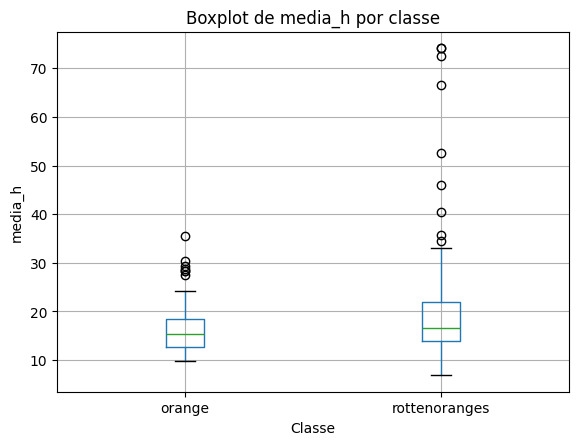

<Figure size 600x400 with 0 Axes>

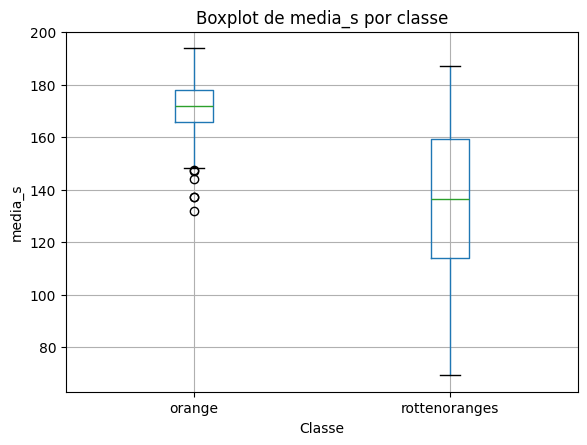

<Figure size 600x400 with 0 Axes>

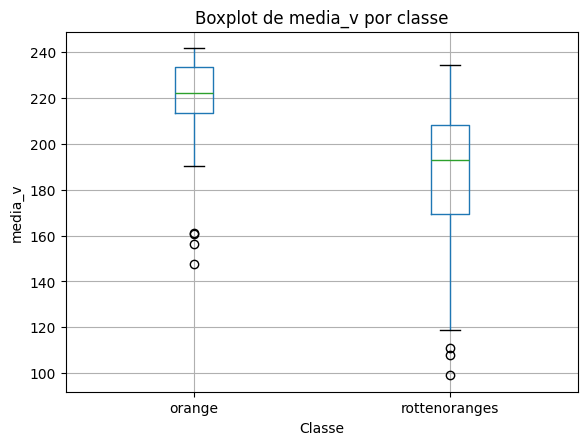

<Figure size 600x400 with 0 Axes>

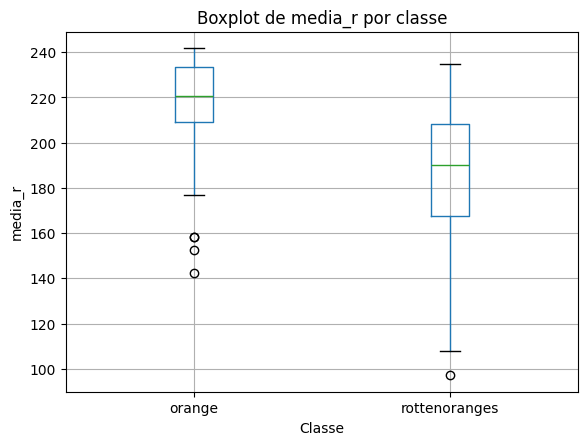

<Figure size 600x400 with 0 Axes>

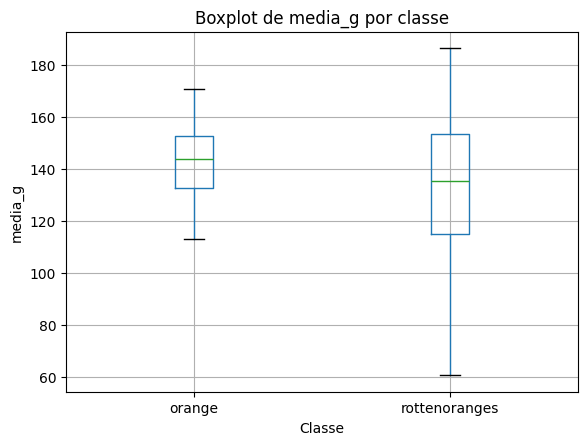

<Figure size 600x400 with 0 Axes>

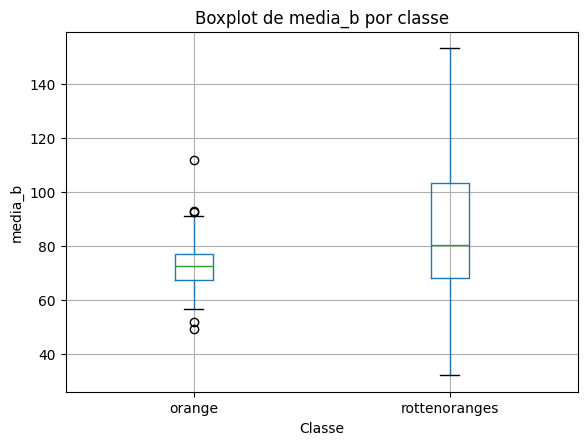

In [151]:
features_para_plotar = [
    "media_h",
    "media_s",
    "media_v",
    "media_r",
    "media_g",
    "media_b"
]

for feature in features_para_plotar:
    plt.figure(figsize=(6, 4))
    df_analise.boxplot(column=feature, by="classe_rotulo")
    plt.title(f"Boxplot de {feature} por classe")
    plt.suptitle("")
    plt.xlabel("Classe")
    plt.ylabel(feature)
    plt.show()

<Figure size 600x400 with 0 Axes>

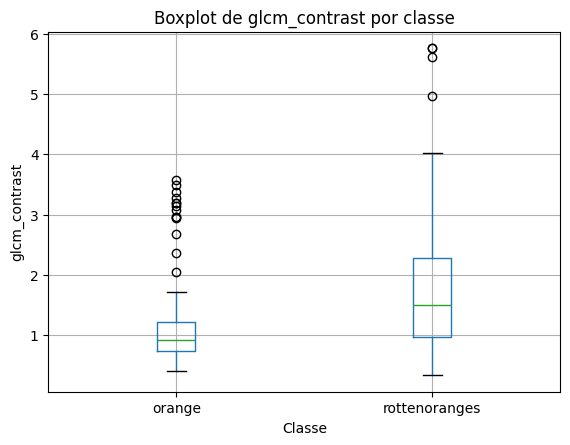

<Figure size 600x400 with 0 Axes>

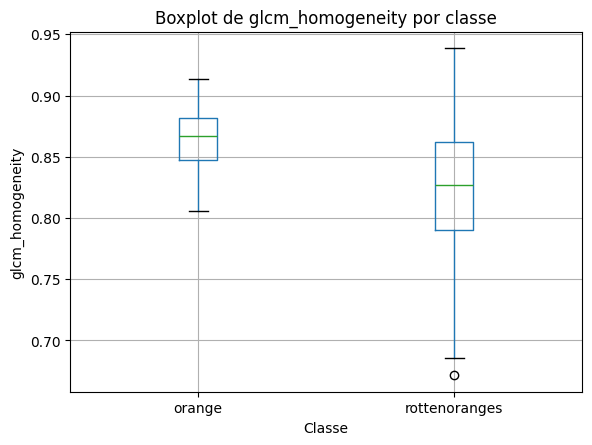

<Figure size 600x400 with 0 Axes>

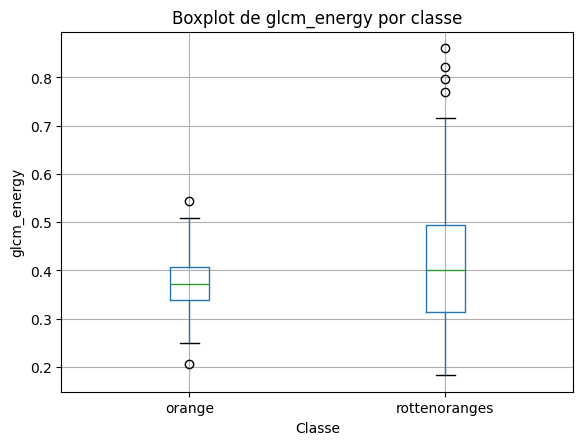

<Figure size 600x400 with 0 Axes>

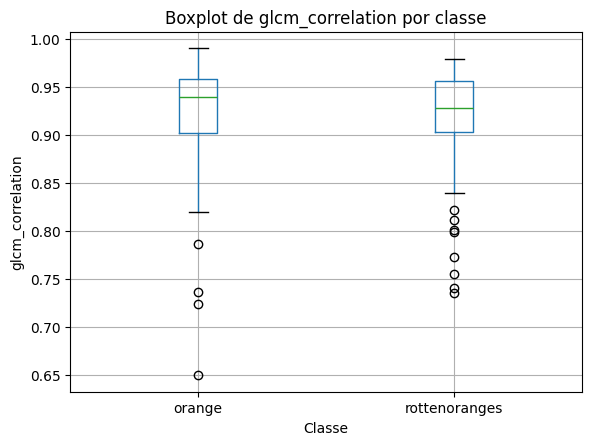

In [152]:
features_textura = [
    "glcm_contrast",
    "glcm_homogeneity",
    "glcm_energy",
    "glcm_correlation"
]

for feature in features_textura:
    plt.figure(figsize=(6, 4))
    df_analise.boxplot(column=feature, by="classe_rotulo")
    plt.title(f"Boxplot de {feature} por classe")
    plt.suptitle("")
    plt.xlabel("Classe")
    plt.ylabel(feature)
    plt.show()

In [153]:
#Na análise inicial, foram comparadas as distribuições das features entre laranjas saudáveis e podres. As features de cor são 
# relevantes porque a podridão altera tonalidade, saturação e brilho da casca. As features de textura também são importantes porque
#  manchas, mofo e regiões deterioradas tornam a superfície menos uniforme. Os boxplots ajudam a identificar quais atributos apresentam
#  maior separação visual entre as classes.

## Boxplots das features de forma

<Figure size 600x400 with 0 Axes>

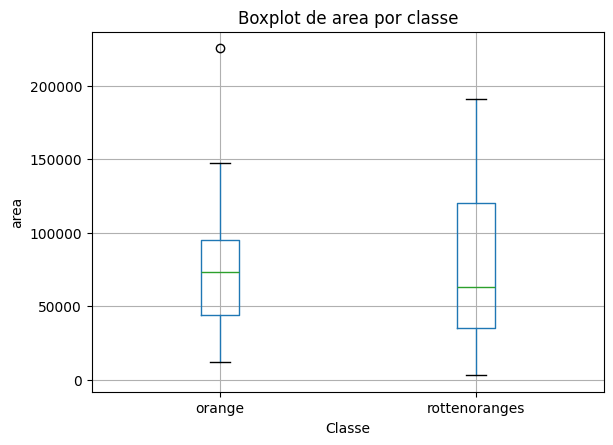

<Figure size 600x400 with 0 Axes>

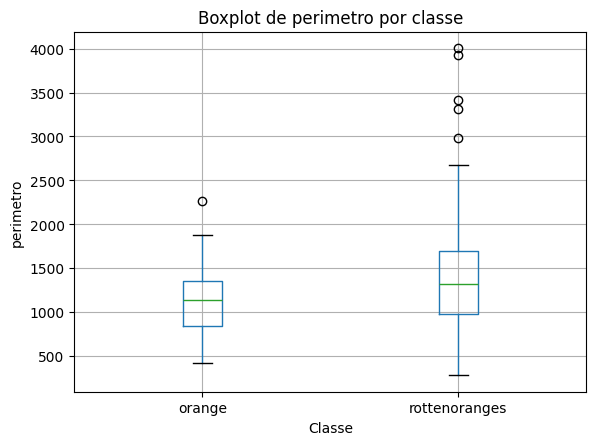

<Figure size 600x400 with 0 Axes>

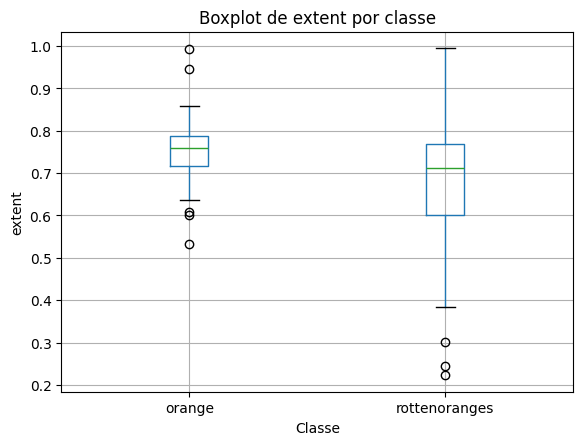

<Figure size 600x400 with 0 Axes>

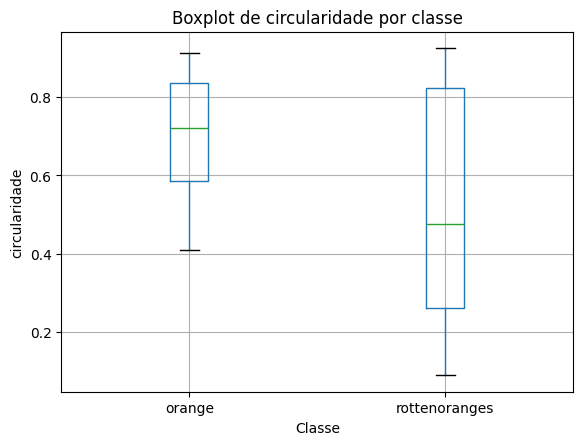

In [154]:
features_forma = [
    "area",
    "perimetro",
    "extent",
    "circularidade"
]

for feature in features_forma:
    plt.figure(figsize=(6, 4))
    df_analise.boxplot(column=feature, by="classe_rotulo")
    plt.title(f"Boxplot de {feature} por classe")
    plt.suptitle("")
    plt.xlabel("Classe")
    plt.ylabel(feature)
    plt.show()

In [155]:
medias = df_analise.groupby("classe_rotulo").mean(numeric_only=True)

diferencas = abs(medias.loc["orange"] - medias.loc["rottenoranges"])
diferencas_ordenadas = diferencas.sort_values(ascending=False)

diferencas_ordenadas

area                5459.340000
perimetro            309.944295
media_s               34.555597
media_v               33.153636
media_r               32.328630
media_b               14.060945
media_g               10.762846
hu_5                   8.306290
hu_6                   8.068394
media_h                3.757753
hu_7                   1.655269
hu_4                   1.365303
rotulo                 1.000000
glcm_contrast          0.622730
hu_3                   0.371163
hu_2                   0.313707
circularidade          0.184728
hu_1                   0.101300
extent                 0.081883
glcm_homogeneity       0.045713
glcm_energy            0.044715
glcm_correlation       0.002983
dtype: float64